IA & Data science (LU3IN0226) -- 2025-2026
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut, Maxellende Julienne.*


# Projet final

<font size="+1" color="RED">**[Q]**</font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

Alexandre Parant - Marc-Antoine Xia

Ce projet peut être fait en binôme ou tout seul.

**Le nom de chaque membre du binôme doit être indiqué dans la boîte ci-dessus**.


**Le compte-rendu est soumis sur la page Moodle.

Si vous êtes en binôme : **<u>un seul rendu doit être remis sur un seul des deux comptes du binôme</u>**.

Les groupes de plus de 2 personnes ne sont pas autorisés.

**La dernière séance de TD-TME11 de votre groupe sera réservée pour travailler sur ce mini-projet.**

<font color="RED" size="+1"><b>[Q]</b></font> **Renommer ce notebook**

**Nom à donner au fichier à poster** : *projet-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme

Voir ci-dessous ce qui est à remettre.



# Projet - mai 2026

<b>Date de remise du compte-rendu : <font size="+1" color="RED">au plus tard le lundi 1er juin 2026, avant 10h</font></b>.
    
<b>Attention!</b> le site Moodle ferme à 20h pile (heure du site Moodle)! prévoyez de vous y connecter au moins 15mn avant la fermeture...
<b>Il n'y aura pas de prolongation possible.</b>

## Travail à faire

Vous devez compléter ce notebook en rajoutant vos expérimentations avec vos algorithmes d'apprentissage (supervisé et non-supervisé) sur les données Fashion MNIST fournies (voir plus loin).

Vous devez appliquer les algorithmes d'apprentissage vus en cours et réaliser une analyse sur les données afin de mettre en évidence des résultats intéressants.

Les données seront chargées par les commandes de chargement des données fournies dans ce notebook (ci-dessous).
Dans le notebook que vous rendrez, le chargement des fichiers de données doit considérer cette arborescence.


## Remarque: utilisation d'IA générative 

Toute utilisation d'une IA générative (ChatGPT, Mistral, Claude,...) pour réaliser certains traitements de ce projet doit **obligatoirement** être indiqué dans votre notebook. De plus, si vous utilisez une telle IA générative, vous devez pouvoir être capable d'expliquer ce qu'elle vous a fourni et que vous avez utilisé.

## Compte-rendu demandé
Ce qui doit être remis avant la date limite : un unique fichier archive compressé (`.tgz`, ou `.zip` uniquement) de nom :
`projet-Nom1_Nom2.tgz` ou `projet-Nom1_Nom2.zip` contenant:
- ce **notebook** complété (et avec vos noms !). Il doit pouvoir être exécuté sans autre apport (pensez à vous en assurer avant de le rendre). 
- votre **librairie iads** complète, c'est à dire votre répertoire `iads/` contenant tous les fichiers python complets.
- un **poster** sous la forme d'un fichier PDF dont le nom est de la forme: *tme11-Nom1_Nom2.pdf* qui correspond à un poster décrivant l'ensemble des expérimentations menées et les résultats obtenus.


**Très important** : les fichiers dans l'archive doivent être placés de façon à respecter la structure de fichiers suivante :

          --projet-Nom1_Nom2/
              --iads/
                  -- Classifiers.py
                  -- etc.
              -- Projet/
                  --  projet-Nom1_Nom2.ipynb


<b>Remarque</b>: 
- **Les <u>fichiers de données ne doivent pas être inclus dans votre archive</u>** ! 
- Pensez à vérifier que votre archive contient bien tous les fichiers demandés et **seulement** les fichiers demandés.
- **Tous les fichiers demandés doivent être soumis avant la date limite**, en une seule archive comme indiqué ci-dessus.

## Soutenance des projets
**Les soutenances auront lieu le <font size="+1" color="RED">mardi 2 juin 2026</font>, à partir de 14h**. 

Un ordre de passage ainsi que la salle de TME où elles auront lieu seront affichées sur le Moodle la veille (la remise d'un compte-rendu à la date d'échéance indiquée (avant le lundi 1er juin 2026, 10h) est **obligatoire** pour passer une soutenance).

La <b>soutenance est obligatoire</b> : <u>tout projet pour lequel la soutenance n'est pas passée sera noté $0$</u>.

Modalités de la soutenance:
- durée de la soutenance : 10 mn pour un binôme, 7 mn pour un monôme ;
- elle a lieu devant un ordinateur avec le notebook et le poster comme support ;
    - elle commence par une rapide présentation des expérimentations réalisées et résultats obtenus (max. 4 à 5mns)
    - puis elle se poursuit par des questions posées individuellement aux membres du binômes sur les expériences ou le code python réalisé.
- la note de soutenance est individuelle pour chaque membre d'un binôme.



In [1]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
%matplotlib inline  

import math
import time
import sys

# pour les dendrogrammes :)
import scipy

# --------------------------------
# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2
# --------------------------------


In [2]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as cl

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev

# importation de Clustering 
from iads import Clustering as clust


## Données pour le projet : Fashion MNIST

Les données sont fournies dans l'archive `data.tgz`. 
Cette archive contient 2 fichiers CSV:
- le fichier `fashion-mnist_train.csv`: ce fichier doit servir à l'entraînement de vos modèles, et leur évaluation en validation croisée,
- le fichier `fashion-mnist_test.csv`: ce fichier ne doit être utilisé que pour évaluer un modèle et il ne doit pas servir pour faire mettre au point le modèle.


Une documentation sur ces données peut être consultée sur la <a href="https://fr.wikipedia.org/wiki/Fashion_MNIST" target="NEW">page wikipedia Fashion MNIST</a>.


#### Chargement des données

In [3]:
data_train = pd.read_csv("../data/fashion-mnist_train.csv")
data_train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
data_test = pd.read_csv("../data/fashion-mnist_test.csv")
data_test

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [5]:
data_train.shape

(60000, 785)

In [6]:
data_test.shape

(10000, 785)

## Tâches à réaliser

### Apprentissage supervisé

*Tâches*: évaluation d'algorithmes et de représentations des données.
- classification binaire
- classification multi-classe

*Etudes suggérées*:
- différents classifiers:
    - perceptron et variantes
    - k-plus proches voisins 
    - arbres de décision
    - ensembles de classifieurs
- analyse des résultats: comparaison des approches et de leurs hyper-paramètres
    - accuracy, temps d'exécutions
    - score fold par fold
    - matrice de confusion
    - ...


### Apprentissage non-supervisé

*Tâche*: présence éventuelle de groupes de données: groupes intra-classes, et/ou groupes interclasses.

*Etudes possibles*:
- étudier l'application d'un clustering hiérarchique et son résultat;
- étudier les résultats de l'application de l'algorithme des k-moyennes, pour différentes valeurs de k: roposer des évaluations des clusters trouvés afin de mettre en évidence les plus intéressants:
    - en utilisant les indices d'évaluation présentés en cours;
    - en comparant par diverses méthodes les clusters trouvés avec les vrais labels des classes (targets y).
- proposer une visualisation des résultats obtenus
- analyse des exemples mal-classés: est-ce qu'ils forment un (ou des) sous-groupes?
- ...


   


## Poster à rendre dans le compte-rendu (format PDF)

Votre poster doit décrire de façon synthétique **l'ensemble des expérimentations** menées sur les données, les résultats obtenus en apprentissage supervisé et en apprentissage non-supervisé ainsi que les conclusions/bilans que vous tirez de ces expérimentations (ie. ce que vous avez appris sur ces données).

**Important*: vous devez indiquer vos noms/prénoms sur le poster.


# Votre travail commence à partir d'ici 

## Chargement des données, normalisation

In [7]:
# Train
data_train_X = data_train.drop(['label'], axis=1)
data_train_Y = data_train["label"]

# Test
data_test_X = data_test.drop(['label'], axis=1)
data_test_Y = data_test["label"]

X = (data_train_X.to_numpy() - 127) / 128
Y = data_train_Y.to_numpy()

Xt = (data_test_X.to_numpy() - 127) / 128
Yt = data_test_Y.to_numpy()

dim = X.shape[1]
Nc = 10

## Verification des données

(60000, 784)
(60000,)


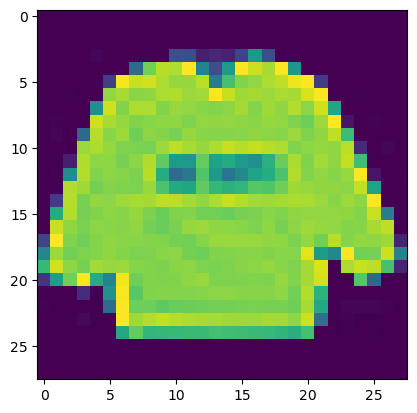

In [8]:
print(X.shape)
print(Y.shape)
plt.figure()
plt.imshow(X[0].reshape((28, 28)))

## Classifieur binaire KNN

In [9]:
# Création de sous jeux de données (de teste et train)
Xm, Ym = ut.getSampleDataset(X, Y, 0, 2, 6000)
Xtm, Ytm = ut.getSampleDataset(Xt, Yt, 0, 2, 600)

Xm38, Ym38 = ut.getSampleDataset(X, Y, 3, 8, 6000)
Xtm38, Ytm38 = ut.getSampleDataset(Xt, Yt, 3, 8, 600)

Xma, Yma = ut.getSampleDataset(X, Y, None, None, 6000)
Xtma, Ytma = ut.getSampleDataset(Xt, Yt, None, None, 600)

[np.float64(0.9433333333333334), np.float64(0.95), np.float64(0.955), np.float64(0.9516666666666667), np.float64(0.9516666666666667), np.float64(0.9533333333333334), np.float64(0.9533333333333334), np.float64(0.9483333333333334)]


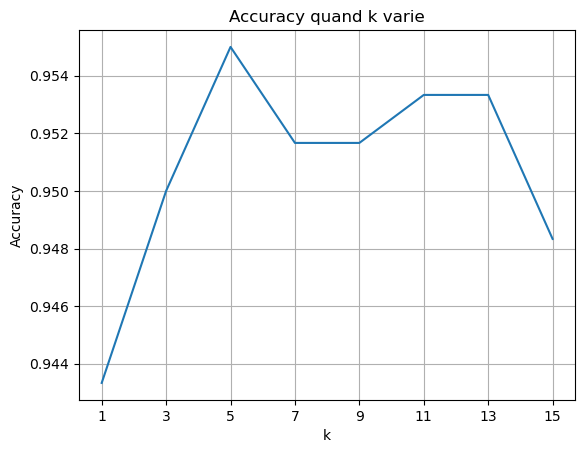

In [11]:
# Variables
L_accuracies = []
k_max = 15

# Éxecute le classifier pour différent k
for k in range(1, k_max+1, 2):
    classifieur_KNN = cl.ClassifierKNN(dim, k)
    classifieur_KNN.train(Xm, Ym)
    accuracy = classifieur_KNN.accuracy(Xtm,Ytm)
    L_accuracies.append(accuracy)
    
print(L_accuracies)

# Informations d'affichage :
plt.title("Accuracy quand k varie")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xticks([v for v in range(1,k_max+1,2)])
plt.plot(range(1,k_max+1, 2), L_accuracies)

plt.show()

le classifier KNN est à une "précision" plutôt bonne pour ce qui est de différencié la classe 0 à 2. 

## Validation croisée

In [10]:
classifieur_KNN = cl.ClassifierKNN(dim, 7)
ev.validation_croisee(classifieur_KNN, (Xm, Ym), 5)

([np.float64(0.9658333333333333),
  np.float64(0.96),
  np.float64(0.9666666666666667),
  np.float64(0.9641666666666666),
  np.float64(0.9608333333333333)],
 np.float64(0.9635),
 np.float64(0.002656229575084881))

Les résultats semblent plutôt satisfaisant dans l'ensemble pour la classification binaire en validation croisée.
Exepté sur l'un des sous jeux de données mais je ne sais pas pourquoi. <---------------------- @JeSuisSurGithub une idée ?

## Classifieur Multiclasse KNN

[np.float64(0.8133333333333334), np.float64(0.81), np.float64(0.8083333333333333), np.float64(0.8216666666666667), np.float64(0.8233333333333334), np.float64(0.81), np.float64(0.8233333333333334), np.float64(0.815), np.float64(0.81), np.float64(0.8066666666666666)]


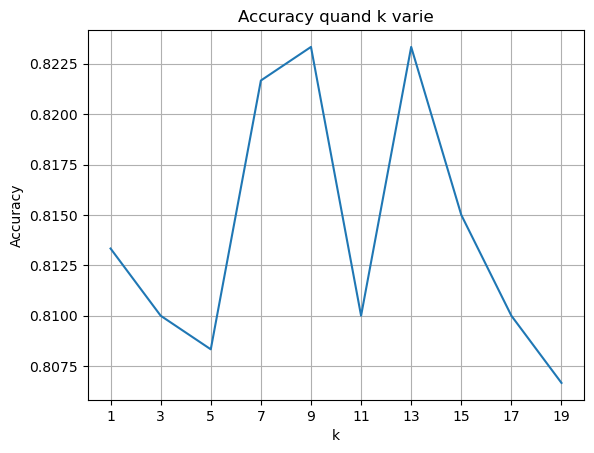

In [15]:
L_accuracies = []
k_max = 20

for k in range(1, k_max+1, 2):
    classifieur_KNN = cl.ClassifierKNN_MC(dim, k, Nc)
    classifieur_KNN.train(Xma, Yma)
    accuracy = classifieur_KNN.accuracy(Xtma,Ytma)
    L_accuracies.append(accuracy)
    
print(L_accuracies)

# Informations d'affichage :
plt.title("Accuracy quand k varie")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xticks([v for v in range(1,k_max+1,2)])
plt.plot(range(1,k_max+1, 2), L_accuracies)

plt.show()

Le multiclasse semble poser un plus gros problème vu qu'elle est dans les alentour de 0.815 par rapport à la non MC qui est de 0.9.
Mais cela est sûrement du au choix que nous avons fait précédement: Choisir les classe 0 et 2 alors que sur le MC, on fait pour toutes les classes
=> Les classes 0 et 2 sont surement plus simple à comparer que d'autres de la base de données et donc l'accuracy est moins élevé quand on fait la moyenne de toutes les classes.
De plus d'après la validation croisé, il peut y avoir des jeux de données ou il ne réussi pas du tous.

## Classifieur Perceptron stabilisé

In [11]:
eps = 1e-3    # learning rate
verbose = False
perceptronStab = cl.ClassifierPerceptronStable(dim, learning_rate=eps, init=True,verbose=False)

In [ ]:
print("Perceptron entre les classes 0 et 2")
if verbose: 
    print("Apprentissage:")
les_differences = perceptronStab.train(Xm,Ym,nb_max=1000,verbose=verbose)

print(f"Accuracy avec data de Train:\t{perceptronStab.accuracy(Xm,Ym):1.4f}")
print(f"Accuracy Test:\t{perceptronStab.accuracy(Xtm,Ytm):1.4f}")

Perceptron entre les classes 0 et 2
Accuracy avec data de Train:	0.9953
Accuracy Test:	0.9267


In [17]:
print("Perceptron entre les classes 3 et 8")
if verbose: 
    print("Apprentissage:")
les_differences = perceptronStab.train(Xm38,Ym38,nb_max=1000,verbose=verbose)
print(f"Accuracy Test:\t{perceptronStab.accuracy(Xtm38,Ytm38):1.4f}")

Perceptron entre les classes 3 et 8
Accuracy Test:	0.9367


In [ ]:
# w au cours des itérations
#allw = np.array(perceptronStab.get_allw()) 

# Tracé de l'évolution des w:
# plt.figure()
#  toutes les coordonnées du vecteur poids: w
# for i in range(dim):
#    plt.plot(allw[:,i], linewidth=0.2)
# plt.title(f'Evolution des w')
# plt.xlabel('Nombre de modifications')
# plt.ylabel('Valeur')

## Classifieur Multi Perceptron stabilisé

In [10]:
eps = 1e-3

clb = cl.ClassifierPerceptronStable(dim, learning_rate=eps, init=True)
perceptron_mc = cl.ClassifierMultiOAA(dim, clb)
perceptron_mc.train(Xma,Yma)
print(f"Accuracy: {perceptron_mc.accuracy(Xtma,Ytma)}")

Accuracy: 0.805


Un scénario similaire se produit, nous avons probablement affaire à la malédiction des dimensions, il y a probablement trop peu d'informations qui peuvent être a travers les 784 pixels

-> Toujours moins bon quand on fait toutes les classes comparé à la 0 et 2


## Réduction de la dimensionalité

/tmp/ipykernel_52668/868070971.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_proj[mask, 0], X_proj[mask, 1], c=colors[c], label=f"Classe {c}", marker="o", s=8, alpha=0.2)


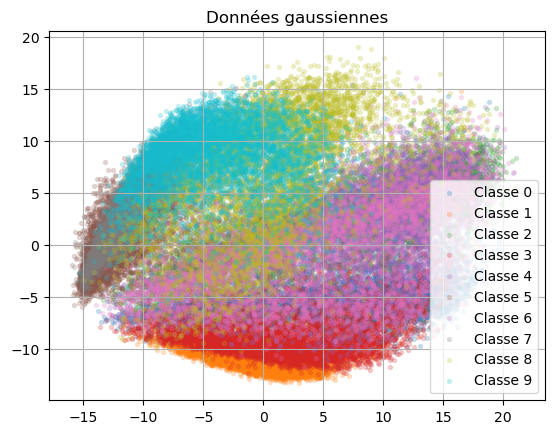

In [19]:
# Visualiser les données en 2D
import matplotlib.colors as mcolors

# 1) calcul des vecteurs propres
Xc = X - np.mean(X, axis=0)
Cov = np.cov(Xc.T)
ValP, VectP = np.linalg.eig(Cov) 

# 3) tri et sélection des 2 vecteurs associés aux 2 plus grandes valeurs propres 
idx = np.argsort(ValP)[::-1]
vproj = VectP[:, idx[:2]] 
X_proj = np.dot(Xc, vproj)

colors = plt.cm.tab10.colors

# 4) affichage (plot) avec un code couleur pour les classes
plt.figure()
for c in range(Nc):
    mask = (Y == c)
    plt.scatter(X_proj[mask, 0], X_proj[mask, 1], c=colors[c], label=f"Classe {c}", marker="o", s=8, alpha=0.2)

plt.title('Données gaussiennes')    
plt.legend()
plt.grid(True)

In [ ]:
eps = 1e-3
ndim = dim // 10

Xr = np.dot(Xma, VectP[:,:ndim])
XTr = np.dot(Xtma, VectP[:,:ndim])
Xr = (Xr - Xr.mean(axis=0)) / (Xr.std(axis=0))
XTr = (XTr - XTr.mean(axis=0)) / (XTr.std(axis=0))

modele_reduit = cl.ClassifierPerceptronStable(input_dimension=ndim, learning_rate=eps, init=True, verbose=False)
clmulti_reduit = cl.ClassifierMultiOAA(ndim, modele_reduit)

tic = time.time()  # On lance le chrono
clmulti_reduit.train(Xr, Yma)
toc = time.time()  # On arrête le chrono

perf_A = clmulti_reduit.accuracy(Xr, Yma)
perf_T = clmulti_reduit.accuracy(XTr, Ytma)

print(f"\nTaux de bonne classification : Train: {perf_A:.4}, Test: {perf_T:.4}, en {toc-tic:0.4} secondes")

Les choses semblent s'améliorer! Ou en tout cas ni dégradées et en revanche accélérées. Essayons de trouver un bon learning rate

[np.float64(0.7866666666666666), np.float64(0.8033333333333333), np.float64(0.8083333333333333), np.float64(0.8233333333333334), np.float64(0.7666666666666667)]


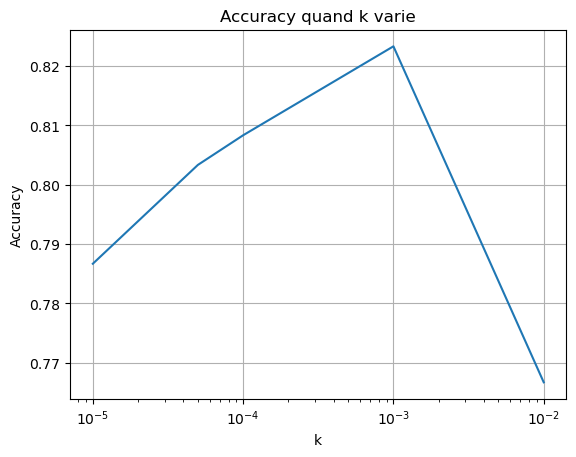

In [ ]:
L_eps = [0.00001, 0.00005, 0.0001, 0.001, 0.01]
L_accuracies = []

for eps in L_eps:
    modele_reduit = cl.ClassifierPerceptronStable(input_dimension=ndim, learning_rate=eps, init=True, verbose=False)
    clmulti_reduit = cl.ClassifierMultiOAA(ndim, modele_reduit)
    clmulti_reduit.train(Xr, Yma)
    accuracy = clmulti_reduit.accuracy(XTr, Ytma)
    L_accuracies.append(accuracy)
    
print(L_accuracies)

# Informations d'affichage :
plt.title("Accuracy quand k varie")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.semilogx(L_eps, L_accuracies)

plt.show()

10e-4 semble être une bonne valeur

In [ ]:
modele_reduit = cl.ClassifierPerceptronStable(input_dimension=ndim, learning_rate=0.001, init=True, verbose=False)
clmulti_reduit = cl.ClassifierMultiOAA(ndim, modele_reduit)
ev.validation_croisee(clmulti_reduit, (Xr, Yma), 5)

([np.float64(0.8316666666666667),
  np.float64(0.8208333333333333),
  np.float64(0.8341666666666666),
  np.float64(0.8208333333333333),
  np.float64(0.8308333333333333)],
 np.float64(0.8276666666666666),
 np.float64(0.005686240703077326))

In [ ]:
dfr = pd.DataFrame.from_records(Xr)
dfr

,0,1,2,3,4,5,6,7,8,9,...,68,69,70,71,72,73,74,75,76,77
0,-1.466605,0.062059,-0.843427,-0.312763,0.370990,0.208280,-0.119850,0.472613,-0.786512,0.622408,...,-0.188078,-0.139482,0.057504,-0.256170,-0.336035,0.601778,0.162012,0.720111,0.054851,-1.117208
1,0.483904,-0.850413,0.201417,-0.416936,1.013517,-0.185885,-1.101881,0.676372,0.240716,-0.646566,...,-0.668936,-0.536329,-1.203683,-1.464532,-0.763769,-0.222402,-0.032071,-0.485880,-0.337282,1.173610
2,-0.619554,1.717065,1.675725,-0.921335,-0.427824,0.159768,-0.955716,0.878121,-1.106975,0.623183,...,-0.526229,-0.482403,0.197380,1.757192,1.291993,-1.654193,1.709618,2.604967,1.664892,0.589852
3,-0.425221,0.656615,-0.310798,-0.015872,-0.716830,0.415262,0.988699,2.559876,1.196545,-1.105388,...,-1.229800,-0.015505,4.680858,2.959807,3.072748,0.346758,0.712262,-0.001063,-2.357741,1.212505
4,0.587189,-1.596373,1.863774,-0.827382,0.521301,-1.269721,1.045125,-0.543281,1.488221,2.014783,...,-0.775236,0.853640,0.026761,-0.660251,0.229403,-0.367201,0.987241,-1.121578,-0.116117,-0.563814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,-0.817262,1.359209,1.347861,0.819179,-0.369113,-0.309545,-1.259092,1.363248,-1.215136,1.061063,...,-0.224950,-0.990390,1.032191,-0.976836,0.083537,-0.169672,1.018786,-0.992250,-0.601092,-0.381239
5996,-0.324653,-1.221878,-0.687241,0.508897,-0.210772,0.490056,-0.352084,0.489196,-1.993734,-1.585463,...,0.489905,-0.561910,-0.354723,0.398530,-0.967559,0.508749,-0.014397,0.924187,-0.284162,0.095637
5997,1.295711,-0.667401,0.510536,-1.124955,1.100541,0.396178,-1.696224,0.405557,0.567416,-0.800912,...,0.435792,1.485175,0.552995,-1.194562,-0.262688,-0.607880,1.782195,0.469642,-0.821067,-1.926247
5998,0.217709,0.810089,-0.259530,1.466174,3.012232,-2.337530,1.440821,-0.125376,-1.403545,0.700726,...,0.473626,-1.386679,-0.476424,-0.608405,-0.104403,0.453478,0.667327,-0.887679,-0.414603,-1.376329


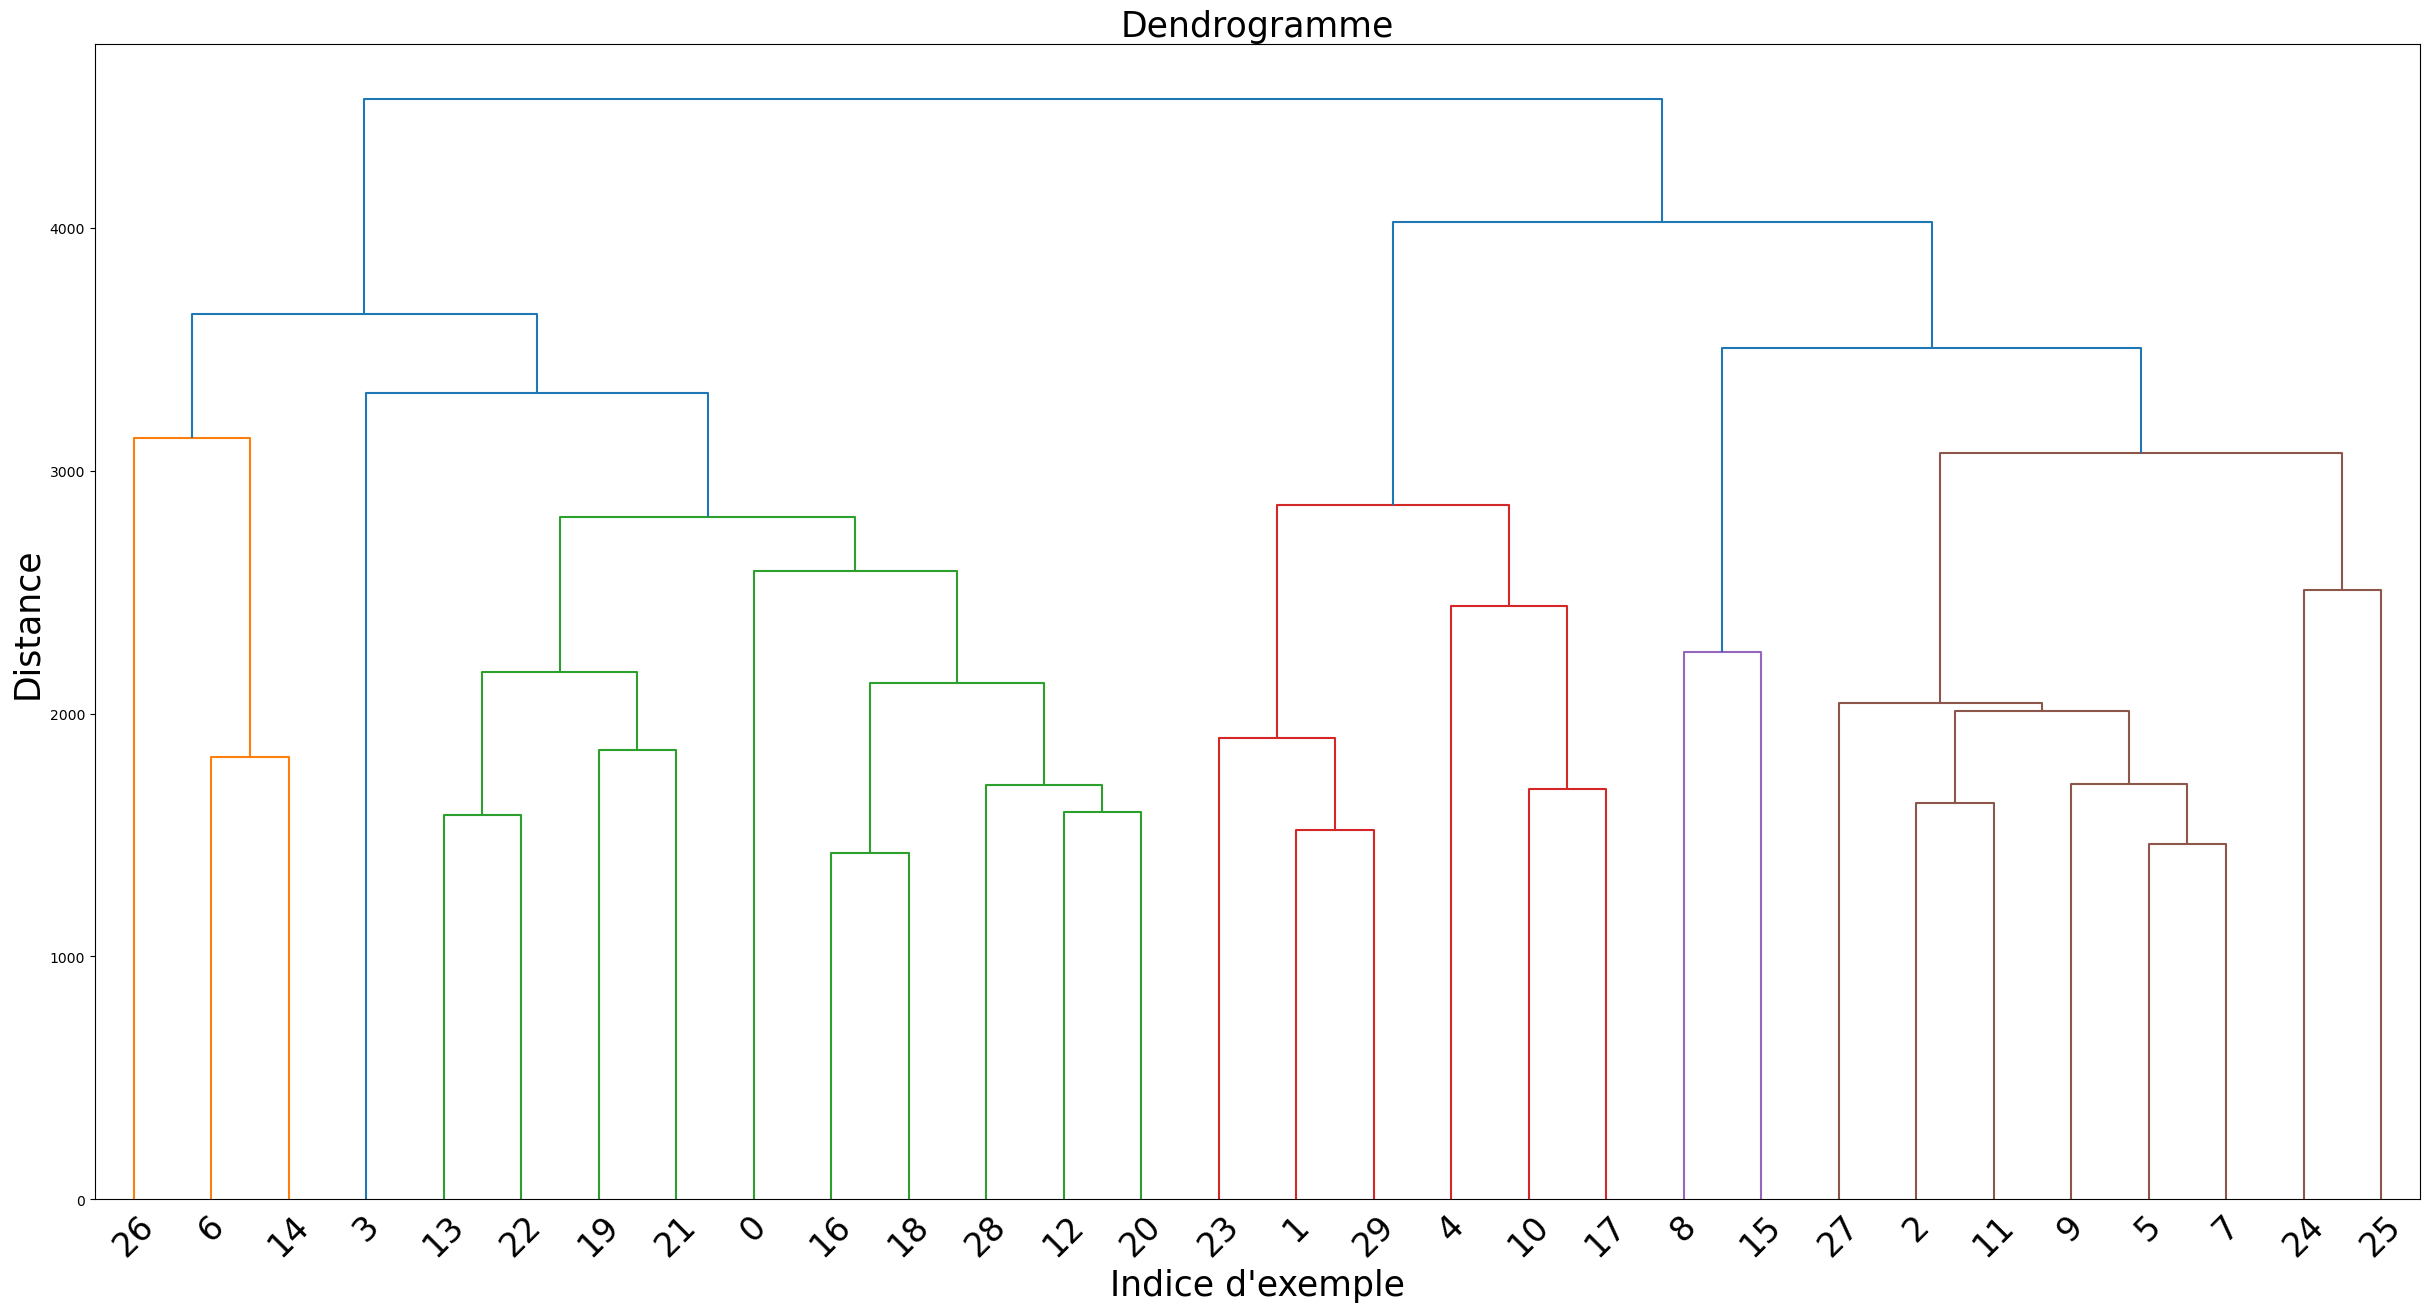

In [ ]:
#Dendograme
import scipy.cluster.hierarchy

# Paramètre de la fenêtre d'affichage: 
plt.figure(figsize=(30, 15)) # taille : largeur x hauteur
plt.title('Dendrogramme', fontsize=25)    
plt.xlabel("Indice d'exemple", fontsize=25)
plt.ylabel('Distance', fontsize=25)

# Construction du dendrogramme pour notre clustering :
linkComplete = clust.LinkageComplete()
scipy.cluster.hierarchy.dendrogram(
    clust.CHA_algorithme(data_test_X.iloc[:30],linkComplete,verbose=False), 
    leaf_font_size=24.,  # taille des caractères de l'axe des X
)

# Affichage du résultat obtenu:
plt.show()

In [ ]:
idx_to_type = {0: "T-shirt/top",
    1: 	"Trouser",
    2:	"Pullover",
    3:  "Dress",
    4: 	"Coat",
    5: 	"Sandal",
    6: 	"Shirt",
    7: 	"Sneaker",
    8: 	"Bag",
    9: 	"Ankle boot"}

for i in range(30):
    plt.figure(figsize=(16, 16))
    plt.title(f"Exemple: {i} Classe: {idx_to_type[Yt[i]]}")
    plt.imshow(Xt[i].reshape((28, 28)))